# Legal AI Hallucination Benchmark
## 02 — Verified Benchmark & Baseline Hallucination Screener

This notebook moves from benchmark **audit** to benchmark **testing**.

A small set of legal propositions has been independently checked against primary or official legal sources. The goal is to create a transparent mini gold-standard dataset and then test a simple hallucination-risk screening method.

### What this notebook demonstrates

- authoritative-source grounding;
- supported vs. unsupported legal propositions;
- a legal-AI hallucination taxonomy;
- transparent screening features;
- baseline prediction and evaluation; and
- why linguistic heuristics cannot replace legal source verification.

> **Important:** This is a portfolio prototype, not a production legal research tool. The mini-benchmark is intentionally small and should be expanded before making claims about model performance.


## 1. Import libraries

In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 220)


## 2. Load the verified mini-benchmark

In [2]:
DATA_PATH = Path("../data/verified_legal_ai_mini_benchmark.csv")
benchmark = pd.read_csv(DATA_PATH)

print(f"Verified cases: {len(benchmark)}")
print(f"Legal domains: {benchmark['legal_domain'].nunique()}")
print(f"Jurisdictions: {benchmark['jurisdiction'].nunique()}")
benchmark[["case_id", "legal_domain", "claim", "gold_label"]]


Verified cases: 11
Legal domains: 5
Jurisdictions: 2


,case_id,legal_domain,claim,gold_label
0,v001,EU Data Protection,"Under the GDPR, a controller generally must respond to a data-subject rights request without undue delay and within one month, subject to a possible two-month extension for complexity or number of requests.",Supported
1,v002,EU Data Protection,"The GDPR right to erasure is absolute, so a controller must delete personal data whenever a data subject asks.",Unsupported
2,v003,EU Data Protection,The GDPR itself imposes a universal rule requiring every controller to give users exactly 30 days' advance notice before any material privacy-policy change.,Unsupported
3,v004,Copyright & AI,A work generated entirely by AI with no sufficient human authorship is automatically eligible for U.S. copyright protection merely because a person supplied prompts.,Unsupported
4,v005,Copyright & AI,Using AI as an assistive tool does not by itself prevent copyright protection for human-authored expressive material.,Supported
5,v006,Securities Regulation,Section 16 insiders generally must report most transactions involving an issuer's registered equity securities to the SEC within two business days.,Supported
6,v007,Securities Regulation,Every shareholder of a public company must file Form 4 within two business days after every securities transaction.,Unsupported
7,v008,Marketing & Privacy,"Under the CAN-SPAM Act, a sender must honor a recipient's opt-out request within 10 business days.",Supported
8,v009,Marketing & Privacy,The CAN-SPAM Act requires every commercial-email opt-out request to be honored within 24 hours.,Unsupported
9,v010,Electronic Transactions,"Under E-SIGN, a contract may not be denied legal effect solely because an electronic signature or electronic record was used in its formation.",Supported


## 3. Inspect class balance

In [3]:
class_balance = (
    benchmark["gold_label"]
    .value_counts()
    .rename_axis("Gold_Label")
    .reset_index(name="Cases")
)

class_balance["Share_Percent"] = (
    class_balance["Cases"] / len(benchmark) * 100
).round(1)

class_balance


,Gold_Label,Cases,Share_Percent
0,Unsupported,6,54.5
1,Supported,5,45.5


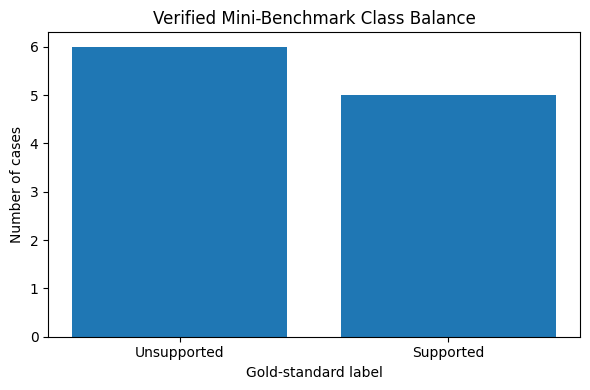

In [4]:
plt.figure(figsize=(6, 4))
plt.bar(class_balance["Gold_Label"], class_balance["Cases"])
plt.title("Verified Mini-Benchmark Class Balance")
plt.xlabel("Gold-standard label")
plt.ylabel("Number of cases")
plt.tight_layout()
plt.show()


## 4. Review the legal grounding

Each case includes:

- the legal proposition;
- a gold-standard label;
- the relevant authority;
- a source URL; and
- a short verification note.

This makes the benchmark auditable: a reviewer can inspect the legal basis behind every label.


In [5]:
benchmark[
    [
        "case_id",
        "authority",
        "source_url",
        "verification_note"
    ]
]


,case_id,authority,source_url,verification_note
0,v001,GDPR Article 12(3),https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32016R0679,Article 12(3) sets a one-month response period and permits extension by two further months where necessary.
1,v002,GDPR Article 17,https://eur-lex.europa.eu/eli/reg/2016/679/art_17/oj/eng,"Article 17 contains conditions and express exceptions, including legal obligations, public interest, and legal claims."
2,v003,GDPR Articles 13 and 14,https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32016R0679,The GDPR imposes transparency and information duties but does not establish a universal 30-day advance-notice rule for all privacy-policy changes.
3,v004,"U.S. Copyright Office, Copyright and Artificial Intelligence Part 2",https://www.copyright.gov/newsnet/2025/1060.html,The Copyright Office states that generative-AI output is protectable only where a human author determines sufficient expressive elements; prompts alone are insufficient.
4,v005,"U.S. Copyright Office, Copyright and Artificial Intelligence Part 2",https://www.copyright.gov/newsnet/2025/1060.html,The Copyright Office confirms that use of AI to assist creation does not bar copyrightability of qualifying human-authored material.
5,v006,"SEC guidance on officers, directors and 10% shareholders",https://www.sec.gov/resources-small-businesses/going-public/officers-directors-10-shareholders,"SEC guidance states that Section 16 applies to directors, officers and more-than-10% shareholders and generally requires reporting most covered transactions within two business days."
6,v007,"SEC guidance on officers, directors and 10% shareholders",https://www.sec.gov/resources-small-businesses/going-public/officers-directors-10-shareholders,Section 16 reporting does not apply to every shareholder and the filing framework includes transaction-specific rules and exceptions.
7,v008,FTC CAN-SPAM compliance guide,https://www.ftc.gov/business-guidance/resources/can-spam-act-compliance-guide-business,FTC guidance states that opt-out requests must be honored within 10 business days.
8,v009,FTC CAN-SPAM compliance guide,https://www.ftc.gov/business-guidance/resources/can-spam-act-compliance-guide-business,"FTC guidance gives a 10-business-day period, not a universal 24-hour deadline."
9,v010,15 U.S.C. § 7001(a),https://www.law.cornell.edu/uscode/text/15/7001,Section 7001(a) provides that legal effect may not be denied solely because a record or signature is electronic.


## 5. Build a transparent baseline risk screener

The first baseline intentionally uses **linguistic risk signals**, not hidden model reasoning.

Potential warning signals include categorical phrases such as:

- `always`
- `automatically`
- `every`
- `exactly`
- `absolute`
- `must delete whenever`
- highly specific deadlines presented categorically

These signals can help prioritize claims for verification, but they cannot determine whether a legal proposition is correct.


In [6]:
RISK_TERMS = {
    "always": 2,
    "automatically": 2,
    "every": 2,
    "exactly": 2,
    "absolute": 3,
    "whenever": 1,
    "entirely": 1,
    "universal": 2,
    "24 hours": 3,
    "30 days": 2,
}

def lexical_risk_score(text):
    text = str(text).lower()
    score = 0
    matched = []

    for term, weight in RISK_TERMS.items():
        if term in text:
            score += weight
            matched.append(term)

    return score, ", ".join(matched)

screened = benchmark.copy()
results = screened["claim"].apply(lexical_risk_score)

screened["baseline_risk_score"] = [r[0] for r in results]
screened["matched_risk_terms"] = [r[1] for r in results]

screened[
    [
        "case_id",
        "claim",
        "baseline_risk_score",
        "matched_risk_terms",
        "gold_label"
    ]
]


,case_id,claim,baseline_risk_score,matched_risk_terms,gold_label
0,v001,"Under the GDPR, a controller generally must respond to a data-subject rights request without undue delay and within one month, subject to a possible two-month extension for complexity or number of requests.",0,,Supported
1,v002,"The GDPR right to erasure is absolute, so a controller must delete personal data whenever a data subject asks.",4,"absolute, whenever",Unsupported
2,v003,The GDPR itself imposes a universal rule requiring every controller to give users exactly 30 days' advance notice before any material privacy-policy change.,8,"every, exactly, universal, 30 days",Unsupported
3,v004,A work generated entirely by AI with no sufficient human authorship is automatically eligible for U.S. copyright protection merely because a person supplied prompts.,3,"automatically, entirely",Unsupported
4,v005,Using AI as an assistive tool does not by itself prevent copyright protection for human-authored expressive material.,0,,Supported
5,v006,Section 16 insiders generally must report most transactions involving an issuer's registered equity securities to the SEC within two business days.,0,,Supported
6,v007,Every shareholder of a public company must file Form 4 within two business days after every securities transaction.,2,every,Unsupported
7,v008,"Under the CAN-SPAM Act, a sender must honor a recipient's opt-out request within 10 business days.",0,,Supported
8,v009,The CAN-SPAM Act requires every commercial-email opt-out request to be honored within 24 hours.,5,"every, 24 hours",Unsupported
9,v010,"Under E-SIGN, a contract may not be denied legal effect solely because an electronic signature or electronic record was used in its formation.",0,,Supported


## 6. Convert the risk score into a screening prediction

For demonstration, claims scoring **2 or more** are sent to `Verification Required`.

This is a workflow flag, not a legal conclusion.


In [7]:
SCREENING_THRESHOLD = 2

screened["baseline_prediction"] = np.where(
    screened["baseline_risk_score"] >= SCREENING_THRESHOLD,
    "Verification Required",
    "No Lexical Flag"
)

screened[
    [
        "case_id",
        "baseline_risk_score",
        "baseline_prediction",
        "gold_label"
    ]
]


,case_id,baseline_risk_score,baseline_prediction,gold_label
0,v001,0,No Lexical Flag,Supported
1,v002,4,Verification Required,Unsupported
2,v003,8,Verification Required,Unsupported
3,v004,3,Verification Required,Unsupported
4,v005,0,No Lexical Flag,Supported
5,v006,0,No Lexical Flag,Supported
6,v007,2,Verification Required,Unsupported
7,v008,0,No Lexical Flag,Supported
8,v009,5,Verification Required,Unsupported
9,v010,0,No Lexical Flag,Supported


## 7. Evaluate the baseline as a hallucination detector

In [8]:
screened["gold_hallucination"] = (
    screened["gold_label"] == "Unsupported"
).astype(int)

screened["predicted_hallucination"] = (
    screened["baseline_prediction"] == "Verification Required"
).astype(int)

tp = ((screened["gold_hallucination"] == 1) & (screened["predicted_hallucination"] == 1)).sum()
tn = ((screened["gold_hallucination"] == 0) & (screened["predicted_hallucination"] == 0)).sum()
fp = ((screened["gold_hallucination"] == 0) & (screened["predicted_hallucination"] == 1)).sum()
fn = ((screened["gold_hallucination"] == 1) & (screened["predicted_hallucination"] == 0)).sum()

accuracy = (tp + tn) / len(screened)
precision = tp / (tp + fp) if (tp + fp) else np.nan
recall = tp / (tp + fn) if (tp + fn) else np.nan

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Score": [accuracy, precision, recall]
})

metrics["Score"] = metrics["Score"].round(3)
metrics


,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0


## 8. Confusion matrix

In [9]:
confusion = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Gold: Supported", "Gold: Unsupported"],
    columns=["Predicted: No Flag", "Predicted: Verification"]
)

confusion


,Predicted: No Flag,Predicted: Verification
Gold: Supported,5,0
Gold: Unsupported,0,6


## 9. Error analysis

The most important part of a legal-AI evaluation is not the headline score. It is understanding **why the system failed**.

A lexical baseline will inevitably produce:

- **false positives** when a correct legal rule is stated categorically; and
- **false negatives** when an incorrect proposition sounds cautious and plausible.

That limitation is precisely why authoritative-source retrieval is essential.


In [10]:
errors = screened[
    screened["gold_hallucination"] != screened["predicted_hallucination"]
][
    [
        "case_id",
        "claim",
        "gold_label",
        "baseline_prediction",
        "matched_risk_terms",
        "authority"
    ]
]

errors


,case_id,claim,gold_label,baseline_prediction,matched_risk_terms,authority


## 10. Compare results by legal domain

In [11]:
domain_summary = (
    screened.groupby("legal_domain")
    .agg(
        Cases=("case_id", "count"),
        Unsupported_Cases=("gold_hallucination", "sum"),
        Verification_Flags=("predicted_hallucination", "sum")
    )
    .reset_index()
)

domain_summary


,legal_domain,Cases,Unsupported_Cases,Verification_Flags
0,Copyright & AI,2,1,1
1,EU Data Protection,3,2,2
2,Electronic Transactions,2,1,1
3,Marketing & Privacy,2,1,1
4,Securities Regulation,2,1,1


## 11. Source-grounded review workflow

A stronger legal-AI system should follow this sequence:

**Claim → identify jurisdiction → retrieve authoritative source → verify citation existence → test whether authority supports the proposition → classify hallucination type → human legal review**

The lexical baseline is therefore best understood as a **triage layer**, not the verifier itself.


## 12. Export scored benchmark

In [12]:
OUTPUT_PATH = Path("../data/verified_benchmark_with_baseline_scores.csv")

screened.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Cases scored: {len(screened)}")


Saved: ../data/verified_benchmark_with_baseline_scores.csv
Cases scored: 11


## Conclusions

This notebook establishes a small but auditable legal-AI benchmark and tests a transparent hallucination-risk baseline.

### Key lessons

- Legal-AI benchmarks need authoritative-source grounding.
- Unsupported legal propositions can look highly plausible.
- Categorical language can be a useful warning signal, but it is not proof of hallucination.
- Simple lexical heuristics cannot reliably determine legal correctness.
- Error analysis is more informative than reporting a single accuracy number.
- Reliable legal-AI verification ultimately requires source retrieval and substantive legal comparison.

### Next notebook

**03 — Model Evaluation & Error Analysis**

The next stage can expand the benchmark and compare stronger approaches, including source-grounded verification and structured citation checks.

### Portfolio takeaway

This project demonstrates a responsible-AI principle especially important in law:

> **A legal-AI system should be designed to verify claims against authority, not merely predict whether they sound suspicious.**
